## Basic Task：

#### Q-Learning For Maze Navigation Task

In [1]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

#### Define a simple 6x6 Maze environment

- Deterministic transitions
- State space: 36 cells
- Actions: 4 directions (Left, Down, Right, Up)
- Invalid actions are not allowed (represented as NaN in R)

In [2]:
# 'S' = Start, 'G' = Goal, 'T' = Trap, 'X' = Obstacle, '.' = Free cell
maze = [
    ['S', '.', '.', '.', 'X', '.'],
    ['.', 'X', '.', '.', 'X', '.'],
    ['.', '.', '.', 'X', '.', '.'],
    ['.', 'X', '.', '.', '.', '.'],
    ['.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', '.', 'T', 'G'],
]

# Maze size
H = 6
W = 6

# Action definitions
# 0 = Left, 1 = Down, 2 = Right, 3 = Up
A = [0, 1, 2, 3]
A_names = {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}

# Convert (row, col) to state id
def rc_to_s(r, c):
    return r * W + c

# Convert state id back to (row, col)
def s_to_rc(s):
    return divmod(s, W)

# Locate Special States
start_state = None
goal_state = None
trap_states = []
obstacle_states = []

for r in range(H):
    for c in range(W):
        s = rc_to_s(r, c)
        cell = maze[r][c]
        
        if cell == 'S':
            start_state = s
        elif cell == 'G':
            goal_state = s
        elif cell == 'T':
            trap_states.append(s)
        elif cell == 'X':
            obstacle_states.append(s)

print("Start state:", start_state)
print("Goal state:", goal_state)
print("Trap states:", trap_states)
print("Obstacle states:", obstacle_states)

Start state: 0
Goal state: 35
Trap states: [34]
Obstacle states: [4, 7, 10, 15, 19, 26, 28]


#### Transition function

In [3]:
# Move deltas for each action
move = {
    0: (0, -1),   # Left
    1: (1, 0),    # Down
    2: (0, 1),    # Right
    3: (-1, 0),   # Up
}

# Returns the next state if the action is valid.
# Returns None if the action is invalid (off-grid or into an obstacle).
def get_next_state(s, a):
    
    r, c = s_to_rc(s)
    dr, dc = move[a]
    r2, c2 = r + dr, c + dc

    # Off-grid -> invalid action
    if r2 < 0 or r2 >= H or c2 < 0 or c2 >= W:
        return None

    s2 = rc_to_s(r2, c2)

    # Into obstacle -> invalid action
    if s2 in obstacle_states:
        return None

    return s2

#### Reward function

- Goal: +10 and terminal
- Trap: -10 and terminal
- Normal move: -0.1 (encourage shorter paths)

In [4]:
# Reward is decided by the next state s2.
def get_reward_and_done(s2):
    
    if s2 == goal_state:
        return 10.0, True
    if s2 in trap_states:
        return -10.0, True
    return -0.1, False

#### Build the R table (NaN = invalid action)

In [5]:
num_states = H * W
num_actions = len(A)

# Initialize all as NaN (all actions invalid by default)
R = np.full((num_states, num_actions), np.nan)

for s in range(num_states):
    # Optional: no actions from terminal states
    if s == goal_state or s in trap_states:
        continue

    # Optional: obstacle cells are never entered, so no actions from them
    if s in obstacle_states:
        continue

    for a in A:
        s2 = get_next_state(s, a)
        if s2 is None:
            continue

        reward, done = get_reward_and_done(s2)
        R[s, a] = reward

print("R table shape:", R.shape)
print("R row for start_state:", R[start_state])
print("Available actions from start:", [A_names[a] for a in np.where(~np.isnan(R[start_state]))[0]])
print(R)

R table shape: (36, 4)
R row for start_state: [ nan -0.1 -0.1  nan]
Available actions from start: ['Down', 'Right']
[[  nan  -0.1  -0.1   nan]
 [ -0.1   nan  -0.1   nan]
 [ -0.1  -0.1  -0.1   nan]
 [ -0.1  -0.1   nan   nan]
 [  nan   nan   nan   nan]
 [  nan  -0.1   nan   nan]
 [  nan  -0.1   nan  -0.1]
 [  nan   nan   nan   nan]
 [  nan  -0.1  -0.1  -0.1]
 [ -0.1   nan   nan  -0.1]
 [  nan   nan   nan   nan]
 [  nan  -0.1   nan  -0.1]
 [  nan  -0.1  -0.1  -0.1]
 [ -0.1   nan  -0.1   nan]
 [ -0.1  -0.1   nan  -0.1]
 [  nan   nan   nan   nan]
 [  nan  -0.1  -0.1   nan]
 [ -0.1  -0.1   nan  -0.1]
 [  nan  -0.1   nan  -0.1]
 [  nan   nan   nan   nan]
 [  nan   nan  -0.1  -0.1]
 [ -0.1  -0.1  -0.1   nan]
 [ -0.1   nan  -0.1  -0.1]
 [ -0.1  -0.1   nan  -0.1]
 [  nan  -0.1  -0.1  -0.1]
 [ -0.1  -0.1   nan   nan]
 [  nan   nan   nan   nan]
 [  nan  -0.1   nan  -0.1]
 [  nan   nan   nan   nan]
 [  nan  10.    nan  -0.1]
 [  nan   nan  -0.1  -0.1]
 [ -0.1   nan  -0.1  -0.1]
 [ -0.1   nan  -0.1 

#### Initialize Q table (same shape as R)

In [6]:
Q = np.zeros(R.shape)

print("Q table shape:", Q.shape)
print("Initial Q row for start_state:", Q[start_state])

Q table shape: (36, 4)
Initial Q row for start_state: [0. 0. 0. 0.]


#### Single-step update

- pick a starting state
- list available actions
- select a greedy action (random tie-breaking)
- execute the transition
- update Q using the Q-learning rule

In [7]:
# Learning parameters
alpha = 0.1   # learning rate
gamma = 0.95  # discount factor

# Start from the actual start state
s = start_state
print(f"\nCurrent state: {s} (row,col={s_to_rc(s)})")

# 1) Available actions: where R[s,a] is NOT NaN
available_actions = np.where(~np.isnan(R[s]))[0]
print("Available actions:", [A_names[a] for a in available_actions])

# 2) Show Q values for available actions
q_values = [Q[s, a] for a in available_actions]
print("Current Q values for available actions:", q_values)

# 3) Greedy action selection with random tie-breaking
best_actions = available_actions[np.where(q_values == np.max(q_values))[0]]
print("Best actions (ties allowed):", [A_names[a] for a in best_actions])

a = np.random.choice(best_actions)
print(f"Selected action: {a} ({A_names[a]}) with Q={Q[s,a]}")

# 4) Environment transition
s2 = get_next_state(s, a)
r = R[s, a]
print(f"Next state: {s2} (row,col={s_to_rc(s2)})")
print(f"Immediate reward r = R[{s},{a}] = {r}")

# 5) Compute TD target: r + gamma * max Q(s2, a')
# Only consider valid actions from s2 (non-NaN in R[s2])
next_available = np.where(~np.isnan(R[s2]))[0]
if len(next_available) == 0:
    max_next_q = 0.0
else:
    max_next_q = np.max(Q[s2, next_available])

td_target = r + gamma * max_next_q
td_error = td_target - Q[s, a]

print(f"max Q(next_state, a') = {max_next_q}")
print(f"TD target = r + gamma*max_next_q = {r} + {gamma}*{max_next_q} = {td_target}")
print(f"TD error  = TD target - Q(s,a) = {td_target} - {Q[s,a]} = {td_error}")

# 6) Update rule
old_value = Q[s, a]
Q[s, a] = Q[s, a] + alpha * td_error

print(f"Q update: Q[{s},{a}] = {old_value} + {alpha}*({td_target} - {old_value}) = {Q[s,a]}")
print("\nUpdated Q row for this state:", Q[s])


Current state: 0 (row,col=(0, 0))
Available actions: ['Down', 'Right']
Current Q values for available actions: [np.float64(0.0), np.float64(0.0)]
Best actions (ties allowed): ['Down', 'Right']
Selected action: 1 (Down) with Q=0.0
Next state: 6 (row,col=(1, 0))
Immediate reward r = R[0,1] = -0.1
max Q(next_state, a') = 0.0
TD target = r + gamma*max_next_q = -0.1 + 0.95*0.0 = -0.1
TD error  = TD target - Q(s,a) = -0.1 - 0.0 = -0.1
Q update: Q[0,1] = 0.0 + 0.1*(-0.1 - 0.0) = -0.010000000000000002

Updated Q row for this state: [ 0.   -0.01  0.    0.  ]


#### Run ONE full episode (ε-greedy)

- Start from start_state
- At each step choose action by ε-greedy (within available actions only)
- Stop when reaching Goal or Trap
- Record total reward and number of steps

In [8]:
# Run one full episode with epsilon-greedy

alpha = 0.1
gamma = 0.95
epsilon = 0.9  # probability of choosing a greedy action

max_steps = 200  # safety limit so we never loop forever

s = start_state
total_reward = 0.0

print("\nRunning ONE episode")
print(f"Start at state {s} (row,col={s_to_rc(s)})")

for t in range(max_steps):

    # List available actions in this state
    available_actions = np.where(~np.isnan(R[s]))[0]

    # If no actions, end
    if len(available_actions) == 0:
        print("No available actions. Ending episode.")
        break

    # Greedy set (ties allowed)
    q_values = [Q[s, a] for a in available_actions]
    best_actions = available_actions[np.where(q_values == np.max(q_values))[0]]

    # Epsilon-greedy selection:
    # With probability epsilon -> pick greedy
    # Otherwise -> pick random among available
    if np.random.uniform() <= epsilon:
        a = np.random.choice(best_actions)
        policy_type = "greedy"
    else:
        a = np.random.choice(available_actions)
        policy_type = "random"

    # Transition + reward
    s2 = get_next_state(s, a)
    r = R[s, a]

    # Determine if terminal (based on next state)
    _, done = get_reward_and_done(s2)

    # Q-learning update
    next_available = np.where(~np.isnan(R[s2]))[0]
    max_next_q = 0.0 if len(next_available) == 0 else np.max(Q[s2, next_available])
    td_target = r + gamma * max_next_q
    Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])

    # Print one step
    print(f"\nStep {t}")
    print(f"  State: {s} {s_to_rc(s)}")
    print(f"  Available actions: {[A_names[x] for x in available_actions]}")
    print(f"  Chosen action: {a} ({A_names[a]}) [{policy_type}]")
    print(f"  Reward: {r}")
    print(f"  Next state: {s2} {s_to_rc(s2)}")
    print(f"  Updated Q[{s},{a}] = {Q[s,a]:.3f}")

    # Move to next state
    s = s2
    total_reward += r

    if done:
        end_type = "GOAL" if s == goal_state else "TRAP"
        print(f"\nEpisode ended: reached {end_type} at state {s} {s_to_rc(s)}")
        break

print(f"\nEpisode total reward: {total_reward}")


Running ONE episode
Start at state 0 (row,col=(0, 0))

Step 0
  State: 0 (0, 0)
  Available actions: ['Down', 'Right']
  Chosen action: 2 (Right) [greedy]
  Reward: -0.1
  Next state: 1 (0, 1)
  Updated Q[0,2] = -0.010

Step 1
  State: 1 (0, 1)
  Available actions: ['Left', 'Right']
  Chosen action: 2 (Right) [greedy]
  Reward: -0.1
  Next state: 2 (0, 2)
  Updated Q[1,2] = -0.010

Step 2
  State: 2 (0, 2)
  Available actions: ['Left', 'Down', 'Right']
  Chosen action: 2 (Right) [greedy]
  Reward: -0.1
  Next state: 3 (0, 3)
  Updated Q[2,2] = -0.010

Step 3
  State: 3 (0, 3)
  Available actions: ['Left', 'Down']
  Chosen action: 0 (Left) [greedy]
  Reward: -0.1
  Next state: 2 (0, 2)
  Updated Q[3,0] = -0.010

Step 4
  State: 2 (0, 2)
  Available actions: ['Left', 'Down', 'Right']
  Chosen action: 1 (Down) [greedy]
  Reward: -0.1
  Next state: 8 (1, 2)
  Updated Q[2,1] = -0.010

Step 5
  State: 8 (1, 2)
  Available actions: ['Down', 'Right', 'Up']
  Chosen action: 3 (Up) [greedy]
  R

#### Define Action Selection Policies

- Epsilon-greedy: balances exploration and exploitation

In [9]:
def choose_action_eps_greedy(Q, R, s, epsilon):
    """
    Epsilon-greedy:
    - With probability epsilon: explore (random valid action)
    - Otherwise: exploit (greedy valid action)
    """
    available_actions = np.where(~np.isnan(R[s]))[0]
    if len(available_actions) == 0:
        return None

    # Greedy set (ties allowed)
    q_values = np.array([Q[s, a] for a in available_actions])
    best_actions = available_actions[np.where(q_values == np.max(q_values))[0]]


    if np.random.random() < epsilon:
        return np.random.choice(available_actions)  # explore
    else:
        return np.random.choice(best_actions)       # exploit

#### Run many episodes until Q matrix converges to final values

In [10]:
# Train Q-learning for many episodes

# Reset Q at the start of training
Q = np.zeros(R.shape)

# Hyperparameters
alpha = 0.1
gamma = 0.95

# Exploration settings
epsilon = 1.0          # start with lots of exploration
epsilon_decay = 0.995  # decay each episode
min_epsilon = 0.05

episodes = 3000
max_steps_per_episode = 200

# Logs for performance
rewards_per_episode = []
steps_per_episode = []
success_per_episode = []  # 1 if reached goal, else 0

for ep in range(episodes):
    s = start_state
    total_reward = 0.0
    steps = 0
    success = 0
    
    for t in range(max_steps_per_episode):
        steps += 1
        
        # Choose action
        a = choose_action_eps_greedy(Q, R, s, epsilon)
        if a is None:
            # No legal actions (terminal state)
            break
        
        # Transition + reward
        s2 = get_next_state(s, a)
        r = R[s, a]
        total_reward += r
        
        # Terminal check (based on next state)
        _, done = get_reward_and_done(s2)
        if s2 == goal_state:
            success = 1
        
        # Q-learning update
        next_available = np.where(~np.isnan(R[s2]))[0]
        max_next_q = 0.0 if len(next_available) == 0 else np.max(Q[s2, next_available])
        td_target = r + gamma * max_next_q
        Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
        
        # Move to next state
        s = s2
        
        if done:
            break
    
    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    
    # Log episode results
    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    success_per_episode.append(success)

print("Training finished.")
print("Final epsilon:", epsilon)
print("Final success rate (last 100 episodes):", np.mean(success_per_episode[-100:]))

Training finished.
Final epsilon: 0.05
Final success rate (last 100 episodes): 1.0


#### Plot performance (reward, steps, success rate)

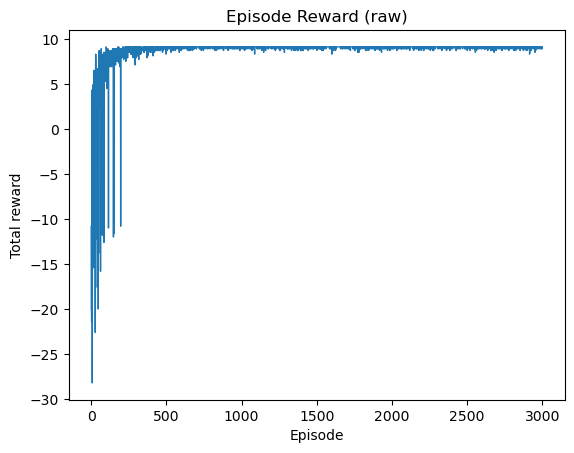

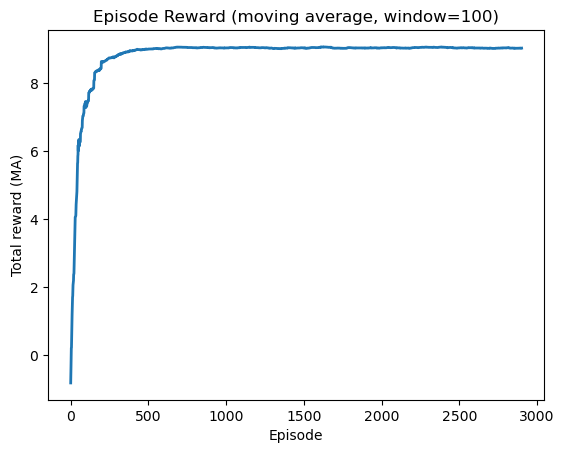

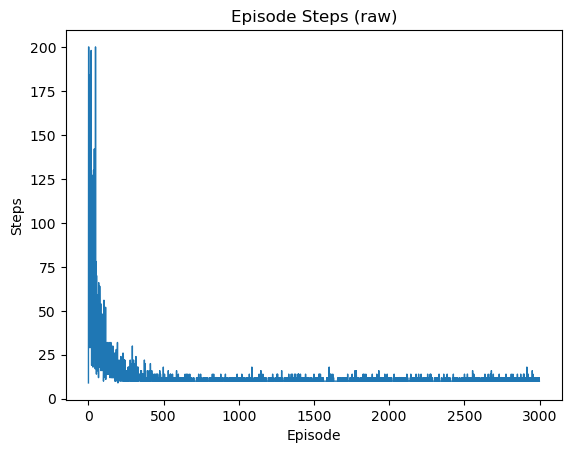

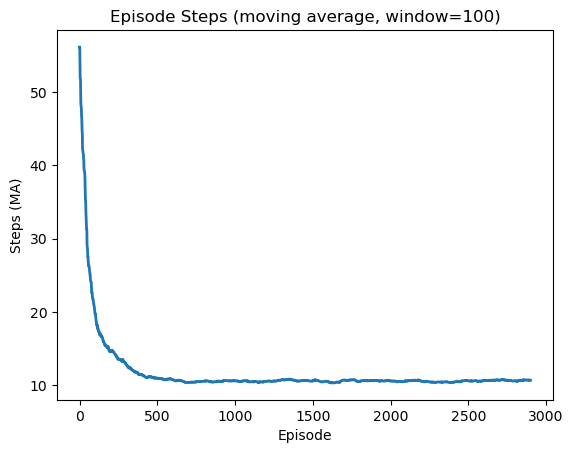

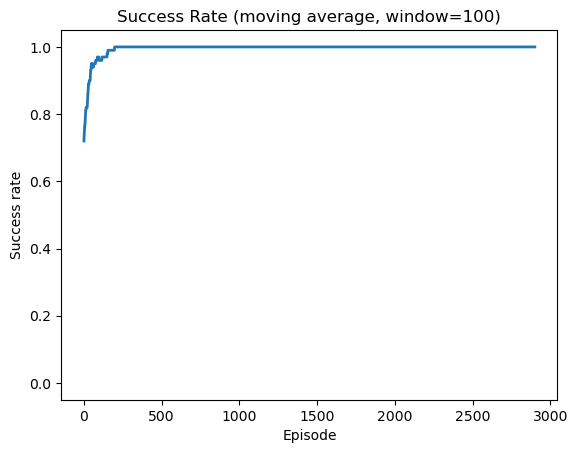

In [11]:
import matplotlib.pyplot as plt
# Plot performance curves

def moving_average(x, window):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode='valid')

window = 100

ma_rewards = moving_average(rewards_per_episode, window)
ma_steps = moving_average(steps_per_episode, window)
ma_success = moving_average(success_per_episode, window)

# 1) Reward curve
plt.figure()
plt.plot(rewards_per_episode, linewidth=1)
plt.title("Episode Reward (raw)")
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.show()

plt.figure()
plt.plot(ma_rewards, linewidth=2)
plt.title(f"Episode Reward (moving average, window={window})")
plt.xlabel("Episode")
plt.ylabel("Total reward (MA)")
plt.show()

# 2) Steps curve
plt.figure()
plt.plot(steps_per_episode, linewidth=1)
plt.title("Episode Steps (raw)")
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.show()

plt.figure()
plt.plot(ma_steps, linewidth=2)
plt.title(f"Episode Steps (moving average, window={window})")
plt.xlabel("Episode")
plt.ylabel("Steps (MA)")
plt.show()

# 3) Success rate curve
plt.figure()
plt.plot(ma_success, linewidth=2)
plt.title(f"Success Rate (moving average, window={window})")
plt.xlabel("Episode")
plt.ylabel("Success rate")
plt.ylim(-0.05, 1.05)
plt.show()

In [12]:
print(Q)

[[ 0.          5.56275763  5.56299292  0.        ]
 [ 5.18482666  0.          5.96104518  0.        ]
 [ 5.55987571  6.38004755  5.5609533   0.        ]
 [ 5.96087522  4.47946294  0.          0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.          3.69458547  0.          0.        ]
 [ 0.          5.96101565  0.          3.97428369]
 [ 0.          0.          0.          0.        ]
 [ 0.          6.82110269  5.95940016  5.96091656]
 [ 6.37988726  0.          0.          4.04800619]
 [ 0.          0.          0.          0.        ]
 [ 0.          7.37925123  0.          1.32906501]
 [ 0.          3.23060768  6.38004649  3.69738056]
 [ 5.72535158  0.          6.82110269  0.        ]
 [ 6.37971414  7.28537125  0.          6.3800325 ]
 [ 0.          0.          0.          0.        ]
 [ 0.          8.28847118  7.72510554  0.        ]
 [ 6.3541393   8.82998525  0.          5.44367203]
 [ 0.          0.19529834  0.          5.07901453]
 [ 0.          0.          0.  

After training, the Q-table converges and defines a deterministic greedy policy. From each state, the agent selects the action with the highest Q-value among the valid actions. Starting from the initial state (0,0), the optimal path learned by the agent is: 0→6→12→13→14→20→21→22→23→29→35

#### Define Action Selection Policies

- Pure greedy: always exploits the best known action, no exploration
- Pure random: always explores randomly, never exploits

In [13]:
def choose_action_greedy(Q, R, s):
    """
    Pure greedy policy: always exploit, no exploration at all (epsilon=0).
    """
    available_actions = np.where(~np.isnan(R[s]))[0]
    if len(available_actions) == 0:
        return None
    q_values = np.array([Q[s, a] for a in available_actions])
    best_actions = available_actions[np.where(q_values == np.max(q_values))[0]]
    return np.random.choice(best_actions)


def choose_action_random(R, s):
    """
    Pure random policy: always explore, never exploit (epsilon=1).
    """
    available_actions = np.where(~np.isnan(R[s]))[0]
    if len(available_actions) == 0:
        return None
    return np.random.choice(available_actions)

#### Experiments with Different Parameters and Policies

In [14]:

def run_experiment(alpha, gamma, epsilon_start, epsilon_decay, min_epsilon, episodes, max_steps, policy):
    """

    Parameters
    
    alpha : learning rate
    gamma : discount factor
    epsilon_start : initial epsilon value
    epsilon_decay : multiplicative decay per episode
    min_epsilon : minimum epsilon value
    episodes : number of training episodes
    max_steps: max steps per episode
    policy : 'eps_greedy', 'greedy', or 'random'
 
    Returns
    
    rewards_per_episode : list of total reward per episode
    steps_per_episode : list of steps taken per episode
    success_per_episode : list of 1 (goal reached) or 0 per episode
    
    """
    Q = np.zeros(R.shape)
    epsilon = epsilon_start
 
    rewards_per_episode = []
    steps_per_episode   = []
    success_per_episode = []
 
    for ep in range(episodes):
        s = start_state
        total_reward = 0.0
        steps = 0
        success = 0
 
        for t in range(max_steps):
            steps += 1
 
            # Action selection
            if policy == 'eps_greedy':
                a = choose_action_eps_greedy(Q, R, s, epsilon)
            elif policy == 'greedy':
                a = choose_action_greedy(Q, R, s)
            elif policy == 'random':
                a = choose_action_random(R, s)
            else:
                raise ValueError(f"Unknown policy: {policy}")
 
            if a is None:
                break
 
            # Environment step
            s2 = get_next_state(s, a)
            r  = R[s, a]
            total_reward += r
 
            _, done = get_reward_and_done(s2)
            if s2 == goal_state:
                success = 1
 
            # Q-learning update
            next_available = np.where(~np.isnan(R[s2]))[0]
            max_next_q = (0.0 if len(next_available) == 0
                          else np.max(Q[s2, next_available]))
            td_target  = r + gamma * max_next_q
            Q[s, a] = Q[s, a] + alpha * (td_target - Q[s, a])
 
            s = s2
            if done:
                break
 
        # Epsilon decay (only for eps_greedy)
        if policy == 'eps_greedy':
            epsilon = max(min_epsilon, epsilon * epsilon_decay)
 
        rewards_per_episode.append(total_reward)
        steps_per_episode.append(steps)
        success_per_episode.append(success)
 
    return rewards_per_episode, steps_per_episode, success_per_episode

#### EXPERIMENT 1 — Compare different Alpha values
##### keep gamma=0.95, epsilon settings fixed

Experiment 1: Comparing different Alpha values
  Running alpha=0.01 ...
    -> Final success rate (last 100 eps): 100.00%
  Running alpha=0.1 ...
    -> Final success rate (last 100 eps): 100.00%
  Running alpha=0.5 ...
    -> Final success rate (last 100 eps): 100.00%
  Running alpha=0.9 ...
    -> Final success rate (last 100 eps): 100.00%


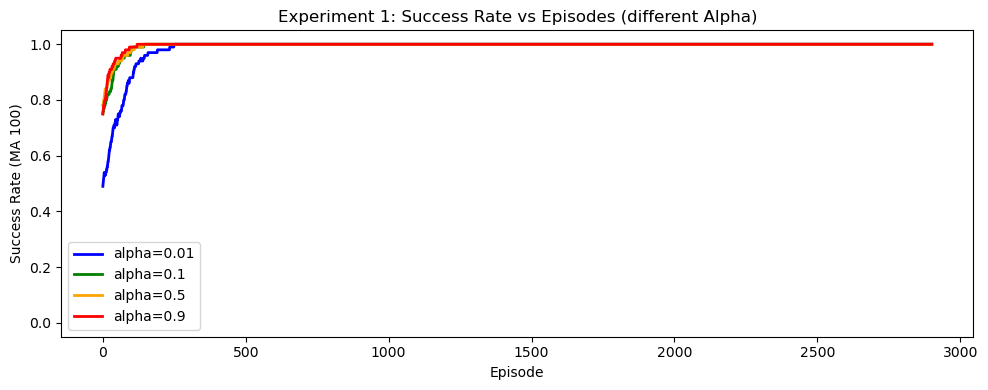

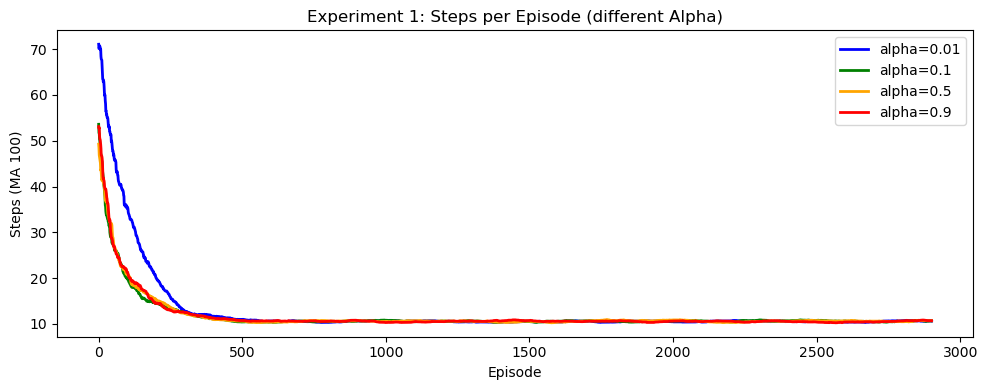

In [15]:
print("=" * 60)
print("Experiment 1: Comparing different Alpha values")
print("=" * 60)

alpha_values = [0.01, 0.1, 0.5, 0.9]
colors_alpha = ['blue', 'green', 'orange', 'red']

results_alpha = {}
for alpha in alpha_values:
    print(f"  Running alpha={alpha} ...")
    r, s, sc = run_experiment(
        alpha=alpha,
        gamma=0.95,
        epsilon_start=1.0,
        epsilon_decay=0.995,
        min_epsilon=0.05,
        episodes=3000,
        max_steps=200,
        policy='eps_greedy'
    )
    results_alpha[alpha] = {'rewards': r, 'steps': s, 'success': sc}
    print(f"    -> Final success rate (last 100 eps): {np.mean(sc[-100:]):.2%}")

# Plot: Success Rate
plt.figure(figsize=(10, 4))
for alpha, color in zip(alpha_values, colors_alpha):
    ma = moving_average(results_alpha[alpha]['success'], window=100)
    plt.plot(ma, label=f'alpha={alpha}', color=color, linewidth=2)
plt.title('Experiment 1: Success Rate vs Episodes (different Alpha)')
plt.xlabel('Episode')
plt.ylabel('Success Rate (MA 100)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Steps per Episode
plt.figure(figsize=(10, 4))
for alpha, color in zip(alpha_values, colors_alpha):
    ma = moving_average(results_alpha[alpha]['steps'], window=100)
    plt.plot(ma, label=f'alpha={alpha}', color=color, linewidth=2)
plt.title('Experiment 1: Steps per Episode (different Alpha)')
plt.xlabel('Episode')
plt.ylabel('Steps (MA 100)')
plt.legend()
plt.tight_layout()
plt.show()

#### EXPERIMENT 2 — Compare different Gamma values
##### keep alpha=0.1, epsilon settings fixed


Experiment 2: Comparing different Gamma values
  Running gamma=0.5 ...
    -> Final success rate (last 100 eps): 100.00%
  Running gamma=0.75 ...
    -> Final success rate (last 100 eps): 100.00%
  Running gamma=0.95 ...
    -> Final success rate (last 100 eps): 100.00%
  Running gamma=0.99 ...
    -> Final success rate (last 100 eps): 100.00%


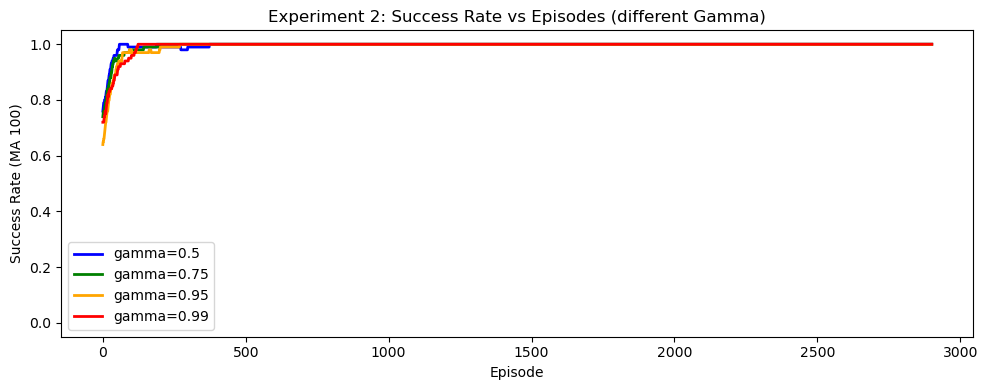

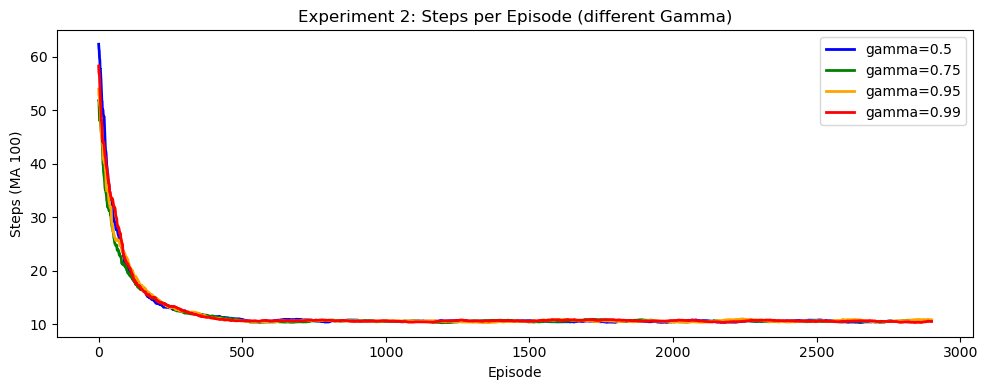

In [16]:

print("\n" + "=" * 60)
print("Experiment 2: Comparing different Gamma values")
print("=" * 60)

gamma_values = [0.5, 0.75, 0.95, 0.99]
colors_gamma = ['blue', 'green', 'orange', 'red']

results_gamma = {}
for gamma in gamma_values:
    print(f"  Running gamma={gamma} ...")
    r, s, sc = run_experiment(
        alpha=0.1,
        gamma=gamma,
        epsilon_start=1.0,
        epsilon_decay=0.995,
        min_epsilon=0.05,
        episodes=3000,
        max_steps=200,
        policy='eps_greedy'
    )
    results_gamma[gamma] = {'rewards': r, 'steps': s, 'success': sc}
    print(f"    -> Final success rate (last 100 eps): {np.mean(sc[-100:]):.2%}")

# Plot: Success Rate
plt.figure(figsize=(10, 4))
for gamma, color in zip(gamma_values, colors_gamma):
    ma = moving_average(results_gamma[gamma]['success'], window=100)
    plt.plot(ma, label=f'gamma={gamma}', color=color, linewidth=2)
plt.title('Experiment 2: Success Rate vs Episodes (different Gamma)')
plt.xlabel('Episode')
plt.ylabel('Success Rate (MA 100)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Steps per Episode
plt.figure(figsize=(10, 4))
for gamma, color in zip(gamma_values, colors_gamma):
    ma = moving_average(results_gamma[gamma]['steps'], window=100)
    plt.plot(ma, label=f'gamma={gamma}', color=color, linewidth=2)
plt.title('Experiment 2: Steps per Episode (different Gamma)')
plt.xlabel('Episode')
plt.ylabel('Steps (MA 100)')
plt.legend()
plt.tight_layout()
plt.show()

#### EXPERIMENT 3 — Compare different Policies
##### keep alpha=0.1, gamma=0.95 fixed


Experiment 3: Comparing different Policies
  Running epsilon-greedy policy ...
  Running pure greedy policy ...
  Running pure random policy ...

  Final success rate (last 100 eps):
    epsilon-greedy : 100.00%
    pure greedy    : 100.00%
    pure random    : 24.00%


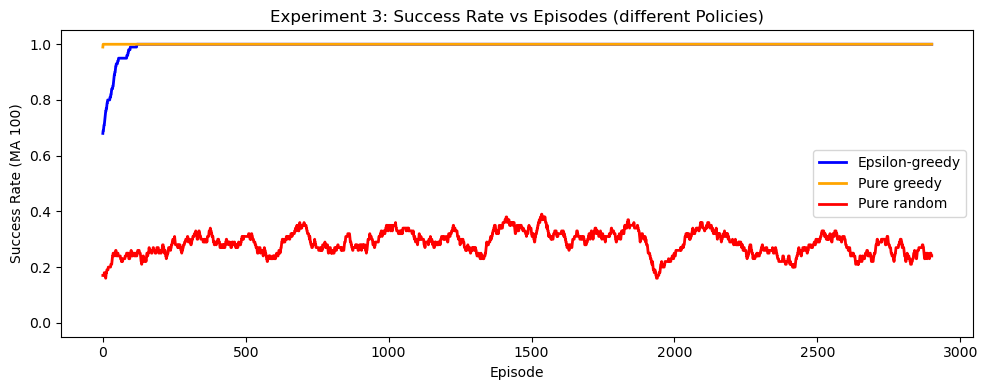

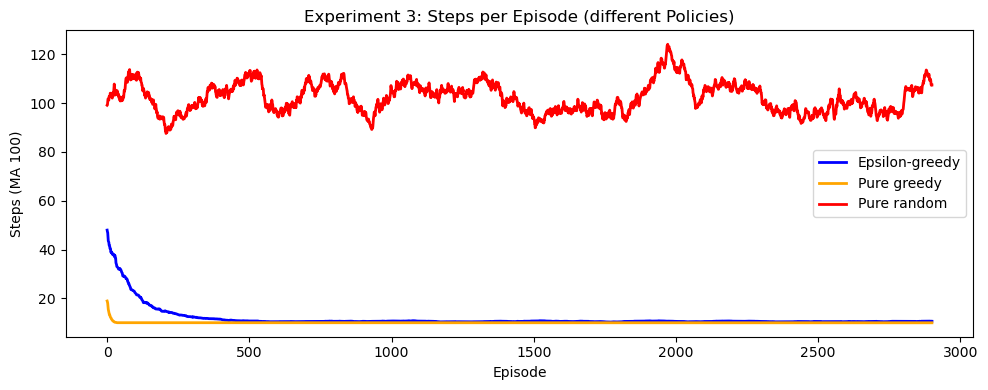

In [17]:
print("\n" + "=" * 60)
print("Experiment 3: Comparing different Policies")
print("=" * 60)

print("  Running epsilon-greedy policy ...")
r_eg, s_eg, sc_eg = run_experiment(
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_decay=0.995,
    min_epsilon=0.05,
    episodes=3000,
    max_steps=200,
    policy='eps_greedy'
)

print("  Running pure greedy policy ...")
r_gr, s_gr, sc_gr = run_experiment(
    alpha=0.1,
    gamma=0.95,
    epsilon_start=0.0,
    epsilon_decay=1.0,
    min_epsilon=0.0,
    episodes=3000,
    max_steps=200,
    policy='greedy'
)

print("  Running pure random policy ...")
r_rd, s_rd, sc_rd = run_experiment(
    alpha=0.1,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_decay=1.0,
    min_epsilon=1.0,
    episodes=3000,
    max_steps=200,
    policy='random'
)

print(f"\n  Final success rate (last 100 eps):")
print(f"    epsilon-greedy : {np.mean(sc_eg[-100:]):.2%}")
print(f"    pure greedy    : {np.mean(sc_gr[-100:]):.2%}")
print(f"    pure random    : {np.mean(sc_rd[-100:]):.2%}")

# Plot: Success Rate
plt.figure(figsize=(10, 4))
plt.plot(moving_average(sc_eg, 100), label='Epsilon-greedy', color='blue',   linewidth=2)
plt.plot(moving_average(sc_gr, 100), label='Pure greedy',    color='orange', linewidth=2)
plt.plot(moving_average(sc_rd, 100), label='Pure random',    color='red',    linewidth=2)
plt.title('Experiment 3: Success Rate vs Episodes (different Policies)')
plt.xlabel('Episode')
plt.ylabel('Success Rate (MA 100)')
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Steps per Episode
plt.figure(figsize=(10, 4))
plt.plot(moving_average(s_eg, 100), label='Epsilon-greedy', color='blue',   linewidth=2)
plt.plot(moving_average(s_gr, 100), label='Pure greedy',    color='orange', linewidth=2)
plt.plot(moving_average(s_rd, 100), label='Pure random',    color='red',    linewidth=2)
plt.title('Experiment 3: Steps per Episode (different Policies)')
plt.xlabel('Episode')
plt.ylabel('Steps (MA 100)')
plt.legend()
plt.tight_layout()
plt.show()

## Advanced Task：DQN

#### Basic DQN CartPole Task

In [18]:
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

In [19]:
class DQN(nn.Module):
    def __init__(self, n_states, n_actions):
        super(DQN, self).__init__()
        
        # 4 input → 128 neurons → 2 output
        self.network = nn.Sequential(
            nn.Linear(n_states, 128),  
            nn.ReLU(),                  
            nn.Linear(128, n_actions) 
        )
    
    def forward(self, x):
        return self.network(x)  # forward propagation 

In [20]:
def select_action(state, epsilon):
    if np.random.random() < epsilon:
        # exploration：random select
        return env.action_space.sample()
    else:
        # exploitation：choose action for greater Q value
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            q_values = policy_net(state_tensor)
            return q_values.argmax().item()

In [21]:
# environment
env = gym.make('CartPole-v1')
n_states = 4   # cart position, cart velocity, pole angle, pole angular velocity
n_actions = 2  # left right

# hyperparameters
alpha = 0.001        # learning rate
gamma = 0.99         # discount factor
epsilon = 1.0        # initial exploration probability
epsilon_decay = 0.995# epsilon decay rate per episode
min_epsilon = 0.01   # minimum exploration probability
episodes = 500       # number of training episodes

In [22]:
# initialise network
policy_net = DQN(n_states, n_actions)

# optimizer (updates network weights during backpropagation)
optimizer = optim.Adam(policy_net.parameters(), lr=alpha)

# loss function (Mean Squared Error)
criterion = nn.MSELoss()

In [23]:
scores = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # select action
        action = select_action(state, epsilon)

        # take action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # compute Q target
        if done:
            q_target = reward
        else:
            q_target = reward + gamma * policy_net(torch.FloatTensor(next_state)).max().item()

        # compute Q predicted
        q_predicted = policy_net(torch.FloatTensor(state))[action]

        # update network
        loss = criterion(q_predicted, torch.tensor(q_target))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # move to next state
        state = next_state

    # decay epsilon
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    scores.append(total_reward)

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1} | Avg Score: {np.mean(scores[-50:]):.1f} | Epsilon: {epsilon:.3f}")

Episode 50 | Avg Score: 19.9 | Epsilon: 0.778
Episode 100 | Avg Score: 21.8 | Epsilon: 0.606
Episode 150 | Avg Score: 18.1 | Epsilon: 0.471
Episode 200 | Avg Score: 18.4 | Epsilon: 0.367
Episode 250 | Avg Score: 25.7 | Epsilon: 0.286
Episode 300 | Avg Score: 36.5 | Epsilon: 0.222
Episode 350 | Avg Score: 51.0 | Epsilon: 0.173
Episode 400 | Avg Score: 55.2 | Epsilon: 0.135
Episode 450 | Avg Score: 74.8 | Epsilon: 0.105
Episode 500 | Avg Score: 138.7 | Epsilon: 0.082


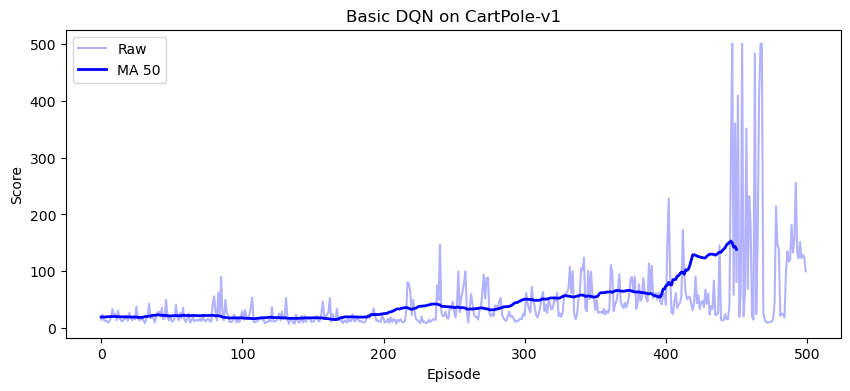

In [24]:

plt.figure(figsize=(10, 4))
plt.plot(scores, alpha=0.3, color='blue', label='Raw')
plt.plot(moving_average(scores, 50), color='blue', linewidth=2, label='MA 50')
plt.title('Basic DQN on CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.show()

#### Experience Replay DQN CartPole

In [25]:
from collections import deque

# reset for new experiment
epsilon = 1.0
policy_net = DQN(n_states, n_actions)
optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
criterion = nn.MSELoss()

# replay memory
memory = deque(maxlen=10000)
batch_size = 64

scores = []
for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False
    while not done:
        # select action
        action = select_action(state, epsilon)
        # execute action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        # store experience in memory
        memory.append((state, action, reward, next_state, done))
        # only train if memory has enough experiences
        if len(memory) >= batch_size:
            # sample a random batch from memory
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)
            # convert to tensors
            states_tensor      = torch.FloatTensor(states)
            actions_tensor     = torch.LongTensor(actions)
            rewards_tensor     = torch.FloatTensor(rewards)
            next_states_tensor = torch.FloatTensor(next_states)
            dones_tensor       = torch.BoolTensor(dones)
            # compute Q predicted for each experience in batch
            q_predicted = policy_net(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)
            # compute Q target for each experience in batch
            with torch.no_grad():
                max_next_q = policy_net(next_states_tensor).max(1)[0]
                q_target = rewards_tensor + gamma * max_next_q * (~dones_tensor)
            # compute loss and update network
            loss = criterion(q_predicted, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        state = next_state
    # decay epsilon after each episode
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    scores.append(total_reward)
    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1} | Avg Score: {np.mean(scores[-50:]):.1f} | Epsilon: {epsilon:.3f}")

/var/folders/q3/zj62tx1d54q9x6l3mt4ldr_w0000gn/T/ipykernel_50269/3427204066.py:33: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1729647065806/work/torch/csrc/utils/tensor_new.cpp:281.)
  states_tensor      = torch.FloatTensor(states)


Episode 50 | Avg Score: 19.3 | Epsilon: 0.778
Episode 100 | Avg Score: 19.0 | Epsilon: 0.606
Episode 150 | Avg Score: 40.4 | Epsilon: 0.471
Episode 200 | Avg Score: 63.0 | Epsilon: 0.367
Episode 250 | Avg Score: 145.9 | Epsilon: 0.286
Episode 300 | Avg Score: 259.3 | Epsilon: 0.222
Episode 350 | Avg Score: 399.6 | Epsilon: 0.173
Episode 400 | Avg Score: 114.4 | Epsilon: 0.135
Episode 450 | Avg Score: 268.9 | Epsilon: 0.105
Episode 500 | Avg Score: 430.8 | Epsilon: 0.082


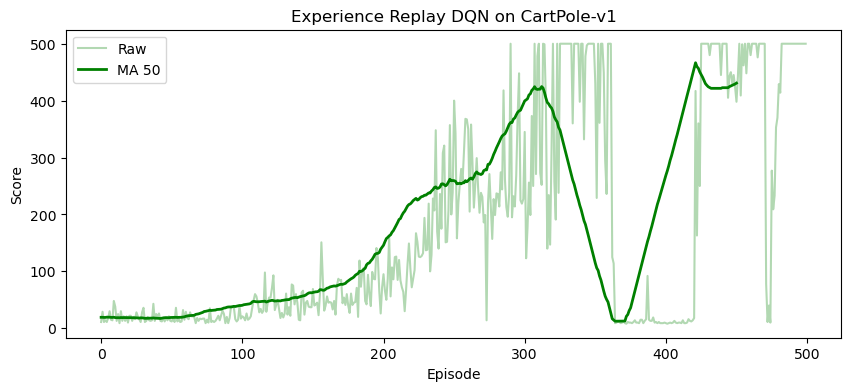

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(scores, alpha=0.3, color='green', label='Raw')
plt.plot(moving_average(scores, 50), color='green', linewidth=2, label='MA 50')
plt.title('Experience Replay DQN on CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.show()

####  Experience Replay + Target Network DQN on CartPole

Episode 50 | Avg Score: 22.5 | Epsilon: 0.778
Episode 100 | Avg Score: 49.1 | Epsilon: 0.606
Episode 150 | Avg Score: 103.5 | Epsilon: 0.471
Episode 200 | Avg Score: 139.1 | Epsilon: 0.367
Episode 250 | Avg Score: 152.3 | Epsilon: 0.286
Episode 300 | Avg Score: 195.1 | Epsilon: 0.222
Episode 350 | Avg Score: 215.9 | Epsilon: 0.173
Episode 400 | Avg Score: 178.7 | Epsilon: 0.135
Episode 450 | Avg Score: 125.2 | Epsilon: 0.105
Episode 500 | Avg Score: 123.5 | Epsilon: 0.082


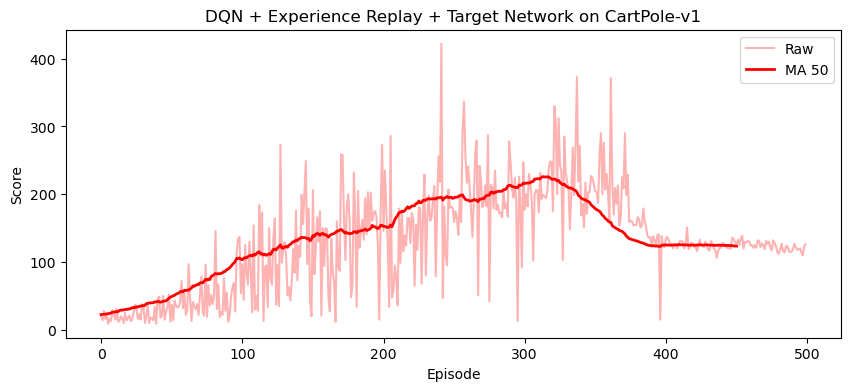

In [27]:
# reset epsilon for new experiment
epsilon = 1.0

# initialise policy network and target network
policy_net = DQN(n_states, n_actions)
target_net = DQN(n_states, n_actions)

# target network starts with same weights as policy network
target_net.load_state_dict(policy_net.state_dict())

# target network is not trained directly
target_net.eval()

# optimizer and loss function
optimizer = optim.Adam(policy_net.parameters(), lr=alpha)
criterion = nn.MSELoss()

# replay memory
memory = deque(maxlen=10000)
batch_size = 64

# target network update frequency
target_update = 10  # copy policy net to target net every 10 episodes

# training Loop
scores = []

for episode in range(episodes):
    state, _ = env.reset()
    total_reward = 0
    done = False

    while not done:
        # select action
        action = select_action(state, epsilon)

        # execute action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward

        # store experience in memory
        memory.append((state, action, reward, next_state, done))

        # only train if memory has enough experiences
        if len(memory) >= batch_size:

            # sample a random batch from memory
            batch = random.sample(memory, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            # convert to tensors
            states_tensor      = torch.FloatTensor(states)
            actions_tensor     = torch.LongTensor(actions)
            rewards_tensor     = torch.FloatTensor(rewards)
            next_states_tensor = torch.FloatTensor(next_states)
            dones_tensor       = torch.BoolTensor(dones)

            # compute Q predicted
            q_predicted = policy_net(states_tensor).gather(1, actions_tensor.unsqueeze(1)).squeeze(1)

            # compute Q target using target network
            with torch.no_grad():
                max_next_q = target_net(next_states_tensor).max(1)[0]
                q_target = rewards_tensor + gamma * max_next_q * (~dones_tensor)

            # compute loss and update network
            loss = criterion(q_predicted, q_target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        state = next_state

    # decay epsilon after each episode
    epsilon = max(min_epsilon, epsilon * epsilon_decay)
    scores.append(total_reward)

    # update target network every target_update episodes
    if (episode + 1) % target_update == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 50 == 0:
        print(f"Episode {episode+1} | Avg Score: {np.mean(scores[-50:]):.1f} | Epsilon: {epsilon:.3f}")

# Plot
plt.figure(figsize=(10, 4))
plt.plot(scores, alpha=0.3, color='red', label='Raw')
plt.plot(moving_average(scores, 50), color='red', linewidth=2, label='MA 50')
plt.title('DQN + Experience Replay + Target Network on CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.show()

## Advanced Task：PPO

#### PPO on CartPole

In [43]:
# hyperparameters
ENV_NAME = 'CartPole-v1'
GAMMA = 0.99       # discount factor
LR_ACTOR = 0.0003  # actor learning rate
LR_CRITIC = 0.001    # critic learning rate
CLIP_EPSILON = 0.2   # PPO clip parameter
K_EPOCHS = 4         # number of epochs per update
N_STEPS = 512        # steps to collect before update
EPISODES = 1000      # total training episodes

In [31]:
# actor network
class Actor(nn.Module):
    def __init__(self, n_states, n_actions):
        super(Actor, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(n_states, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, n_actions),
            nn.Softmax(dim=-1)  # output action probabilities
        )

    def forward(self, x):
        return self.network(x)

In [32]:
# critic network
class Critic(nn.Module):
    def __init__(self, n_states):
        super(Critic, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(n_states, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)  # output single value V(s)
        )

    def forward(self, x):
        return self.network(x)

In [33]:
env = gym.make(ENV_NAME)
n_states  = env.observation_space.shape[0]  # 4
n_actions = env.action_space.n              # 2

# initialise actor and critic
actor = Actor(n_states, n_actions)
critic = Critic(n_states)

# separate optimizers for actor and critic
actor_optimizer = optim.Adam(actor.parameters(),  lr=LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)

criterion = nn.MSELoss()

In [34]:
def select_action(state):
    state_tensor = torch.FloatTensor(state)
    
    with torch.no_grad():
        probs = actor(state_tensor)  # get action probabilities
    
    # sample action from probability distribution
    dist = torch.distributions.Categorical(probs)
    action = dist.sample()
    
    # return action and its log probability
    return action.item(), dist.log_prob(action).item()

In [35]:
def compute_returns(rewards, dones, last_value, gamma):
    returns = []
    R = last_value

    for r, done in zip(reversed(rewards), reversed(dones)):
        if done:
            R = 0  # reset if episode ended
        R = r + gamma * R
        returns.insert(0, R)

    return returns

In [36]:
def ppo_update(states, actions, old_log_probs, returns, advantages):
    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions)
    old_log_probs = torch.FloatTensor(old_log_probs)
    returns = torch.FloatTensor(returns)
    advantages = torch.FloatTensor(advantages)

    # normalise advantages
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    for _ in range(K_EPOCHS):
        # actor loss (PPO clip)
        probs = actor(states)
        dist = torch.distributions.Categorical(probs)
        new_log_probs = dist.log_prob(actions)

        # compute ratio r_t(θ)
        ratio = torch.exp(new_log_probs - old_log_probs)

        # clipped objective
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1 - CLIP_EPSILON, 1 + CLIP_EPSILON) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()

        # critic loss
        values = critic(states).squeeze()
        critic_loss = criterion(values, returns)

        # update actor
        actor_optimizer.zero_grad()
        actor_loss.backward()
        actor_optimizer.step()

        # update critic
        critic_optimizer.zero_grad()
        critic_loss.backward()
        critic_optimizer.step()

In [44]:
# reset networks
actor = Actor(n_states, n_actions)
critic = Critic(n_states)
actor_optimizer  = optim.Adam(actor.parameters(),  lr = LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr = LR_CRITIC)

scores = []
step_count = 0

# storage for collected data
states_buf = []
actions_buf = []
log_probs_buf = []
rewards_buf = []
dones_buf = []

state, _ = env.reset()
episode_reward = 0
episode_scores = []

for episode in range(EPISODES * 200):  # run by steps
    # select action
    action, log_prob = select_action(state)

    # execute action
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    # store data
    states_buf.append(state)
    actions_buf.append(action)
    log_probs_buf.append(log_prob)
    rewards_buf.append(reward)
    dones_buf.append(done)

    episode_reward += reward
    state = next_state
    step_count += 1

    if done:
        episode_scores.append(episode_reward)
        scores.append(episode_reward)
        episode_reward = 0
        state, _ = env.reset()

        if len(scores) >= EPISODES:
            break

    # update every c
    if step_count % N_STEPS == 0:
        # compute last value for bootstrapping
        with torch.no_grad():
            last_value = critic(torch.FloatTensor(state)).item()

        # compute returns
        returns = compute_returns(rewards_buf, dones_buf, last_value, GAMMA)

        # compute advantages
        values = []
        with torch.no_grad():
            for s in states_buf:
                v = critic(torch.FloatTensor(s)).item()
                values.append(v)

        advantages = [r - v for r, v in zip(returns, values)]

        # PPO update
        ppo_update(states_buf, actions_buf, log_probs_buf, returns, advantages)

        # clear buffer
        states_buf    = []
        actions_buf   = []
        log_probs_buf = []
        rewards_buf   = []
        dones_buf     = []

    if done and len(scores) % 50 == 0 and len(scores) > 0:
        print(f"Episode {len(scores)} | Avg Score: {np.mean(scores[-50:]):.1f}")

print(f"Training complete! Final avg score: {np.mean(scores[-50:]):.1f}")

Episode 50 | Avg Score: 20.6
Episode 100 | Avg Score: 23.6
Episode 150 | Avg Score: 27.2
Episode 200 | Avg Score: 38.2
Episode 250 | Avg Score: 43.2
Episode 300 | Avg Score: 47.2
Episode 350 | Avg Score: 64.5
Episode 400 | Avg Score: 78.5
Episode 450 | Avg Score: 98.8
Episode 500 | Avg Score: 128.7
Episode 550 | Avg Score: 169.6
Episode 600 | Avg Score: 245.2
Episode 650 | Avg Score: 330.0
Episode 700 | Avg Score: 326.9
Episode 750 | Avg Score: 395.1
Episode 800 | Avg Score: 457.5
Episode 850 | Avg Score: 434.8
Episode 900 | Avg Score: 480.1
Episode 950 | Avg Score: 418.6
Training complete! Final avg score: 464.5


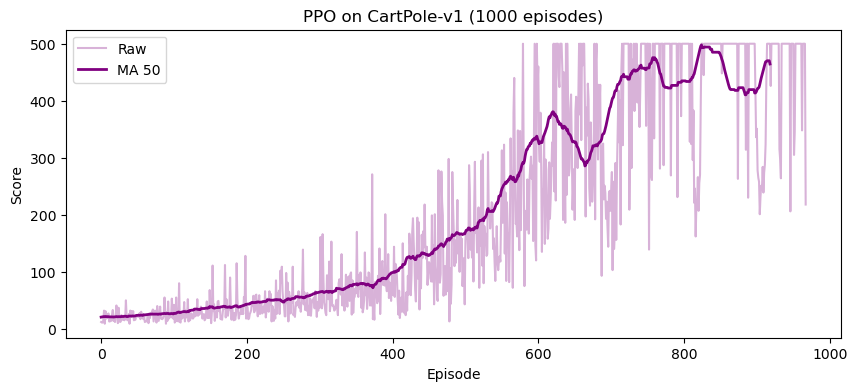

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(scores, alpha=0.3, color='purple', label='Raw')
plt.plot(moving_average(scores, 50), color='purple', linewidth=2, label='MA 50')
plt.title('PPO on CartPole-v1 (1000 episodes)')
plt.xlabel('Episode')
plt.ylabel('Score')
plt.legend()
plt.show()